# Phylogeny and centrality constraints

The constraints in [Linear and group constraints](02_Linear_Group_Constraints.md) act on names
and hand-drawn groups. **Phylogeny** and **centrality** constraints act on the *structure* of
the asset network instead — the graph of how assets co-move. Rather than telling the optimiser
"tech ≤ 30%", you tell it "don't pile into a tightly-knit cluster" or "tilt toward (away from)
the hubs of the correlation network". The groups are discovered from the data, not declared.

`PortfolioOptimisers.jl` builds the network with a `NetworkEstimator` (or a clustering
estimator) and then exposes two families:

  - **Phylogeny constraints** (`SemiDefinitePhylogenyEstimator`,
    `IntegerPhylogenyEstimator`) via the `ple` keyword — limit joint exposure to
    network-linked assets.
  - **Centrality constraints** (`CentralityConstraint` built from a
    `CentralityEstimator`) via the `cte` keyword — bound the portfolio's average
    network centrality.

> **When to reach for this**
>
> Reach for these when your diversification concern is *structural* rather than by label: you
> do not want a book that looks diversified by sector but is actually one big correlated bet,
> or you want to deliberately tilt toward stable hubs or peripheral diversifiers. They need no
> hand-built groups — the structure comes from the covariance. The semidefinite phylogeny and
> centrality forms are convex; the integer phylogeny form needs a MIP solver.

In [1]:
using PortfolioOptimisers, CSV, TimeSeries, DataFrames, PrettyTables, Clarabel, StatsPlots,
      GraphRecipes

resfmt = (v, i, j) -> begin
    return if j == 1
        v
    else
        isa(v, AbstractFloat) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. ReturnsResult data

In [2]:
X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
pr = prior(EmpiricalPrior(), rd)

slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))

res_base = optimise(MeanRisk(; obj = MinimumRisk(),
                             opt = JuMPOptimiser(; pe = pr, slv = slv)))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
     │          

## 2. The asset network

A `NetworkEstimator` turns the covariance into a graph: assets are nodes, and edges link
assets whose returns are connected after filtering out the noisy links (a minimum-spanning-tree
or similar backbone). Both constraint families below read this graph. You do not have to build it
by hand — the estimators take a `NetworkEstimator()` and construct it from the prior internally.

## 3. Phylogeny constraints

A `SemiDefinitePhylogenyEstimator` adds a semidefinite constraint that discourages
holding assets which are neighbours in the network — concentrated, mutually-correlated bets.
Passing it through `ple` reshapes the minimum-risk portfolio toward combinations that are
diversified in *network* terms, not just in count.

In [3]:
res_phylo = optimise(MeanRisk(; obj = MinimumRisk(),
                              opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                  ple = SemiDefinitePhylogenyEstimator(;
                                                                                       pl = NetworkEstimator()))))

pretty_table(DataFrame("Asset" => rd.nx, "Baseline" => res_base.w,
                       "Phylogeny" => res_phylo.w); formatters = [resfmt],
             title = "Minimum risk: baseline vs network-phylogeny constrained")

Minimum risk: baseline vs network-phylogeny constrained
┌────────┬──────────┬───────────┐
│  Asset │ Baseline │ Phylogeny │
│ String │  Float64 │   Float64 │
├────────┼──────────┼───────────┤
│   AAPL │    0.0 % │     0.0 % │
│    AMD │    0.0 % │     0.0 % │
│    BAC │    0.0 % │   0.005 % │
│    BBY │    0.0 % │     0.0 % │
│    CVX │  7.432 % │  12.063 % │
│     GE │  0.806 % │   0.109 % │
│     HD │    0.0 % │   0.001 % │
│    JNJ │ 36.974 % │  52.972 % │
│    JPM │  0.749 % │    1.95 % │
│     KO │ 11.161 % │   21.12 % │
│    LLY │    0.0 % │   0.001 % │
│    MRK │ 17.467 % │   0.024 % │
│   MSFT │    0.0 % │   0.001 % │
│    PEP │  8.978 % │   0.029 % │
│      ⋮ │        ⋮ │         ⋮ │
└────────┴──────────┴───────────┘
                   6 rows omitted


The constraint moves a large fraction of the book — it is enforcing genuine structural
diversification, not a cosmetic tweak. For a *hard* limit on the number of names drawn from each
network cluster, `IntegerPhylogenyEstimator` imposes an integer (cardinality-style)
version; being combinatorial it needs a MIP solver (see
[Budget Constraints](01_Budget_Constraints.md) for the Pajarito/HiGHS setup).

## 4. Centrality constraints

Centrality measures how *central* each asset is in the network — a hub that co-moves with many
others, versus a periphery name that diversifies. A `CentralityEstimator` scores every
asset, and a `CentralityConstraint` bounds the portfolio's weighted-average centrality
through `cte`. You can push the book toward hubs (`comp = >=`, a higher floor) or toward the
periphery (`comp = <=`, a lower ceiling).

In [4]:
res_hub = optimise(MeanRisk(; obj = MinimumRisk(),
                            opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                cte = CentralityConstraint(;
                                                                           A = CentralityEstimator(),
                                                                           B = 0.20,
                                                                           comp = >=))))
res_periph = optimise(MeanRisk(; obj = MinimumRisk(),
                               opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                   cte = CentralityConstraint(;
                                                                              A = CentralityEstimator(),
                                                                              B = 0.08,
                                                                              comp = <=))))

centrality = centrality_vector(CentralityEstimator(), pr).X
avg_centrality(w) = sum(w .* centrality)
pretty_table(DataFrame("Portfolio" =>
                           ["Baseline", "Hub-tilted (≥ 0.20)", "Periphery (≤ 0.08)"],
                       "Avg centrality" =>
                           [avg_centrality(res_base.w), avg_centrality(res_hub.w),
                            avg_centrality(res_periph.w)]);
             title = "Average network centrality of the portfolio")

Average network centrality of the portfolio
┌─────────────────────┬────────────────┐
│           Portfolio │ Avg centrality │
│              String │        Float64 │
├─────────────────────┼────────────────┤
│            Baseline │       0.143427 │
│ Hub-tilted (≥ 0.20) │            0.2 │
│  Periphery (≤ 0.08) │      0.0799999 │
└─────────────────────┴────────────────┘


The constraint binds in both directions — the hub tilt lifts the average centrality to its floor,
the periphery tilt drops it to its ceiling. Centrality is not one number: a
`CentralityEstimator` accepts different algorithms (degree, eigenvector, closeness,
betweenness, …), each emphasising a different notion of "central", so the right one depends on
what kind of connectedness you care about.

## 5. Comparing the structural constraints

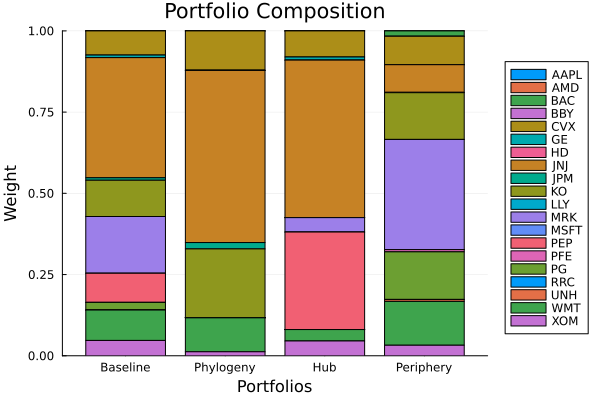

In [5]:
results = [res_base, res_phylo, res_hub, res_periph]
labels = ["Baseline", "Phylogeny", "Hub", "Periphery"]

plot_stacked_bar_composition(results, rd; xticks = (1:length(labels), labels))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*